# **THE END-TO-END PIPELINE OF CALIFORNIA HOUSING DATASET**

### SECTION 1: LOADING REAL-WORLD DATA

In [35]:
# Import Libraries
import pandas as pd
import numpy as np
import plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [36]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
#Add target column (house price)
df['MedHouseVal'] = data.target  # Price in $100,000s


In [37]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [38]:
df.shape

(20640, 9)

In [39]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [40]:
# MedHouseVal is in $ multiply it with 100,000$
df['MedHouseVal']*100000

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: MedHouseVal, Length: 20640, dtype: float64

In [41]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [42]:
#datatype check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [43]:
#Null value Check
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [44]:
print(df['Longitude'].value_counts())

Longitude
-118.31    162
-118.30    160
-118.29    148
-118.27    144
-118.32    142
          ... 
-123.25      1
-123.28      1
-123.13      1
-123.12      1
-123.43      1
Name: count, Length: 844, dtype: int64


In [45]:
print(df['Latitude'].value_counts())

Latitude
34.06    244
34.05    236
34.08    234
34.07    231
34.04    221
        ... 
35.97      1
35.86      1
35.85      1
35.89      1
35.88      1
Name: count, Length: 862, dtype: int64


In [46]:
df['HouseAge'].nunique()

52

In [47]:
corr = df.corr()
print(corr['MedHouseVal'].sort_values(ascending=False))

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


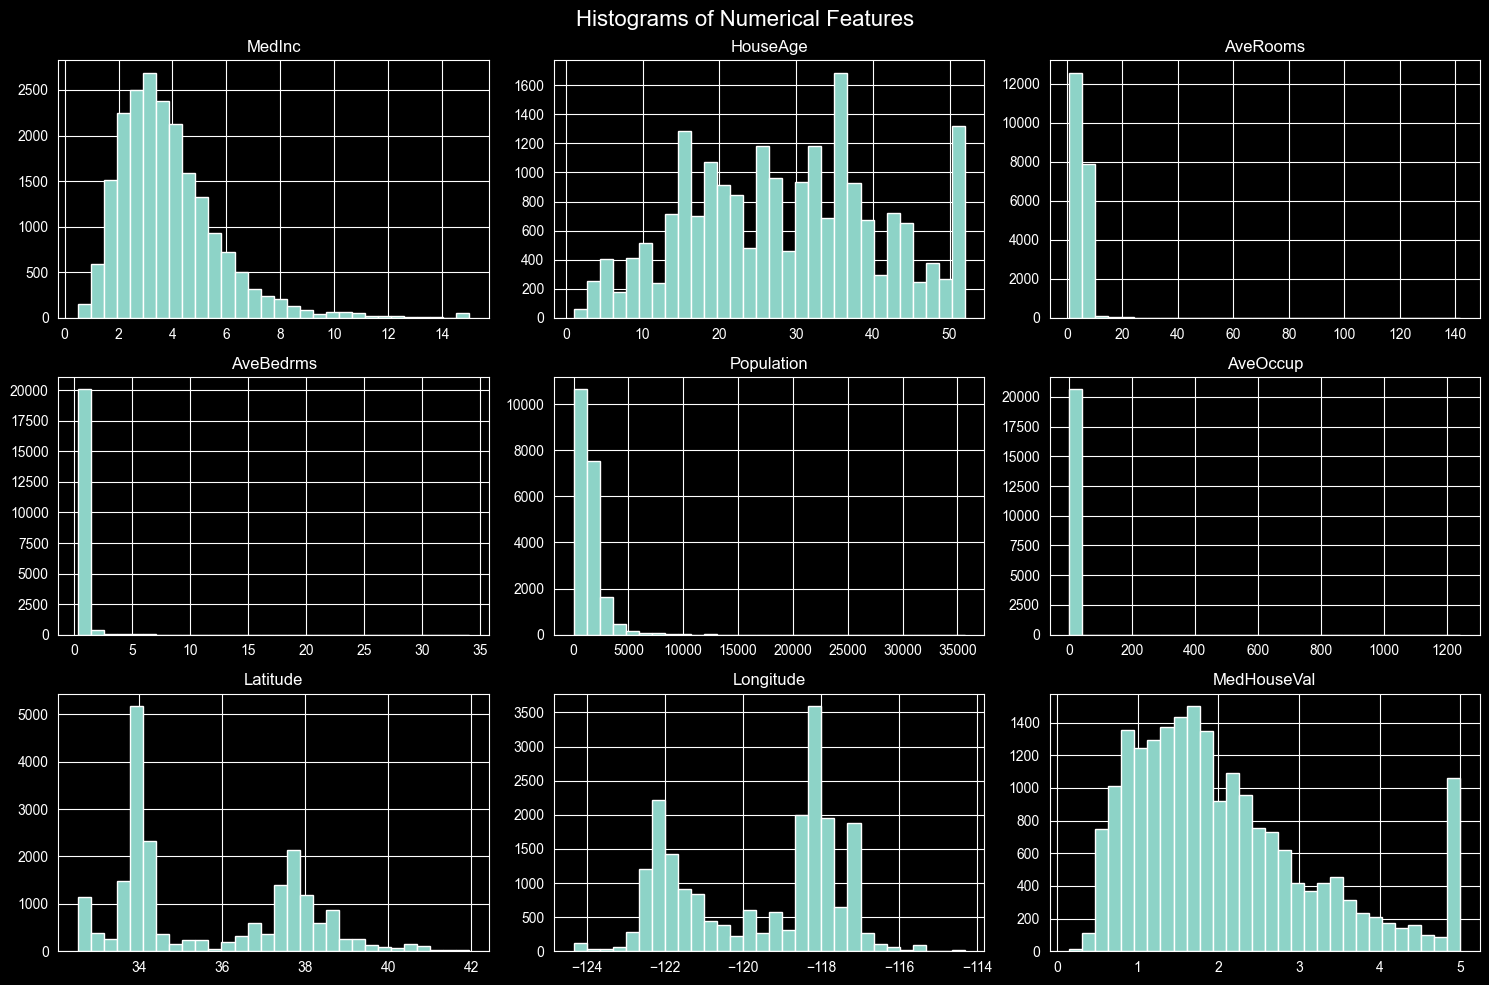

In [48]:
# Histogram of each numeric feature
df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

#### Observation:-

* Most features like Population, AveRooms, and AveOccup are right-skewed (long tail on the right side).
* MedInc shows moderate skewness with a few high-value outliers.
* HouseAge is fairly evenly distributed but shows a peak at higher values (capped data).
* AveRooms and AveBedrms contain extreme high values indicating possible outliers.
* Population and AveOccup have very large ranges, showing high variation in data.
* MedHouseVal (target) is roughly normally distributed but has a cap at higher values.

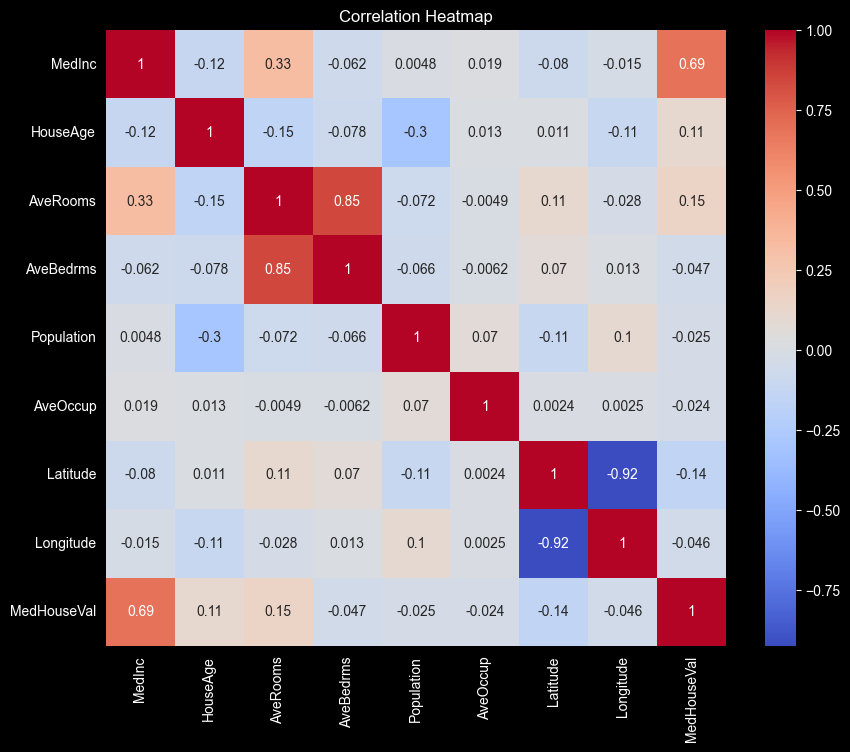

In [49]:
# Correlation Heatmap (only if there are 4 or more numeric columns)
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10,8))
    corr_matrix = numeric_df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()

##### Observation:-

* MedInc (0.688) → Strong positive correlation; most important feature affecting house prices
* AveRooms (0.15) → Weak positive relation; more rooms slightly increase price
* HouseAge (0.10) → Very weak impact on house pricing
* Latitude (-0.14) → Moderate negative correlation; location plays a role
* Other features (Population, AveOccup, AveBedrms, Longitude) → Very weak or no significant correlation

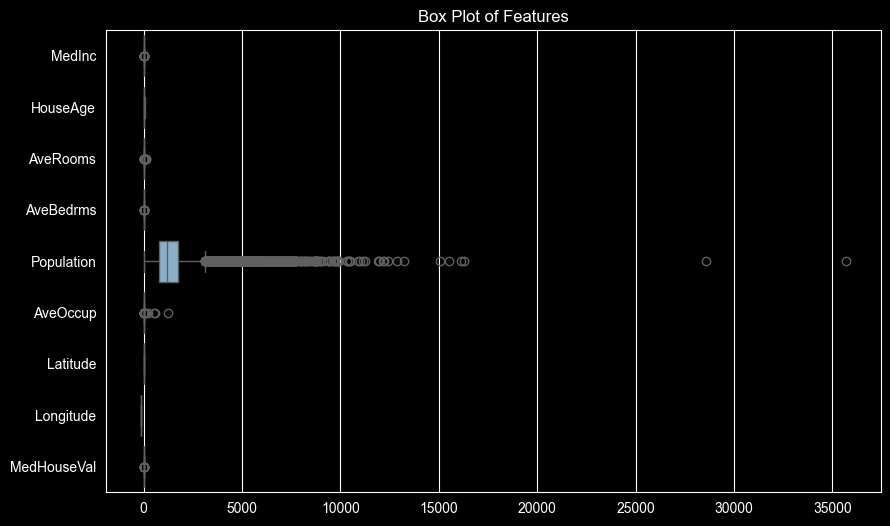

In [50]:
# Box plot for a visual identification of outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=df, orient='h')
plt.title('Box Plot of Features')
plt.show()

#### Observation:-
* Population and AveOccup have many extreme values, showing abnormal or uneven data.
* AveRooms and AveBedrms have high values on one side(Right Skewed, with some large outliers.
* MedInc is mostly balanced but has a few high values.
* HouseAge, Latitude, and Longitude are stable with very few outliers.
* Overall, outliers are present and can affect Linear Regression performance.

In [51]:
# Apply log transformation to reduce skewness in numerical features
df['MedInc'] = np.log1p(df['MedInc'])

In [52]:
df['AveRooms'] = np.log1p(df['AveRooms'])
df['AveBedrms'] = np.clip(df['AveBedrms'], 0, df['AveBedrms'].quantile(0.99))

In [53]:
df['Population'] = np.log1p(df['Population'])

In [54]:
df['AveOccup'] = np.clip(df['AveOccup'], 0, 10)

In [55]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,2.232720,41.0,2.077455,1.023810,5.777652,2.555556,37.88,-122.23,4.526
1,2.230165,21.0,1.979364,0.971880,7.784057,2.109842,37.86,-122.22,3.585
2,2.111110,52.0,2.228738,1.073446,6.208590,2.802260,37.85,-122.24,3.521
3,1.893579,52.0,1.919471,1.073059,6.326149,2.547945,37.85,-122.25,3.413
4,1.578195,52.0,1.985385,1.081081,6.338594,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,0.940124,25.0,1.799307,1.133333,6.740519,2.560606,39.48,-121.09,0.781
20636,1.268861,18.0,1.962070,1.315789,5.877736,3.122807,39.49,-121.21,0.771
20637,0.993252,17.0,1.825443,1.120092,6.915723,2.325635,39.43,-121.22,0.923
20638,1.053336,18.0,1.845223,1.171920,6.609349,2.123209,39.43,-121.32,0.847


In [56]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,1.516995,28.639486,1.828722,1.076287,7.025503,2.931212,35.631861,-119.569704,2.068558
std,0.358677,12.585558,0.231938,0.160058,0.736238,0.821141,2.135952,2.003532,1.153956
min,0.405398,1.000000,0.613104,0.333333,1.386294,0.692308,32.540000,-124.350000,0.149990
25%,1.270715,18.000000,1.693911,1.006079,6.669498,2.429741,33.930000,-121.800000,1.196000
50%,1.511781,29.000000,1.829236,1.048780,7.062192,2.818116,34.260000,-118.490000,1.797000
75%,1.748025,37.000000,1.953365,1.099526,7.453562,3.282261,37.710000,-118.010000,2.647250
max,2.772595,52.000000,4.962209,2.127541,10.482430,10.000000,41.950000,-114.310000,5.000010


## Feature Engineering

In [57]:
df['RoomsPerHousehold'] = df['AveRooms'] / df['AveOccup']
df['BedroomsPerRoom'] = df['AveBedrms'] / df['AveRooms']
df['PopulationPerHousehold'] = df['Population'] / df['AveOccup']

## SECTION 2: THE PRE-PROCESSING WRAPPER

In [58]:
# 3. Split features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']


In [59]:
y = np.log1p(y)

In [60]:
from sklearn.model_selection import train_test_split

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [61]:
from sklearn.preprocessing import StandardScaler

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## SECTION 3: MODEL TRAINING & ANALYSIS

In [62]:
from sklearn.linear_model import LinearRegression

# 6. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [63]:
# 7. Predictions
y_pred = model.predict(X_test_scaled)

In [64]:
y_pred = np.expm1(y_pred)
y_test = np.expm1(y_test)

IMPORTANT:-
If don't reverse transformation (undo) it it gives worng MAE

In [65]:
from sklearn.metrics import mean_absolute_error

# 8. Evaluation
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 0.4557620091473104


In [66]:
from sklearn.metrics import r2_score

linear_r2 = r2_score(y_test, y_pred)
print(f"R-Squared Score: {r2:.2f}")

R-Squared Score: 0.67


# DAY 9:HYPERPARAMETER TUNING


#### What is Hyperparameter?

A hyperparameter is a setting of a machine learning model that is set before training starts and is not learned from the data.

Hyperparameters are the “manual tuning knobs” of a model that control how it learns.

Think of a model like a guitar:

Weights = music produced (learned from data)
Hyperparameters = tuning of strings before playing

If tuning is wrong, music (model performance) will be bad.

* Linear Regression: Doesn't have many knobs.
* Ridge/Lasso Regression: Has a knob called alpha (Regularization strength).
* Random Forest: Has knobs like n_estimators (number of trees).

#### GRID SEARCH CROSS-VALIDATION

In [67]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.1, 1.0, 10.0,50.0, 100.0, 500.0]}
# 3. Initialize Grid Search
# cv=5 means 5-fold Cross-Validation (splitting data 5 times to be sure)
grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
# 4. RUN THE SEARCH
grid_search.fit(X_train_scaled, y_train)

print(f"Best Alpha Found: {grid_search.best_params_}")
print(f"Best R2 Score: {grid_search.best_score_:.4f}")

Best Alpha Found: {'alpha': 10.0}
Best R2 Score: 0.6991


In [68]:
rigid_r2 = r2_score(y_test, y_pred)
print(f"Without Hyperparameter Tuning R2 Score: {r2:.2f}")

Without Hyperparameter Tuning R2 Score: 0.67


#### Understood the concept of Cross-Validation and why it prevents "luck-based" results.

Cross-validation works by splitting the dataset into multiple parts (folds) and training/testing the model several times. Each fold gets a chance to be the test set, and the final performance is calculated as an average of all runs. This removes dependency on a single train-test split and ensures the model evaluation is fair, stable, and not based on luck.

**In a Markdown cell, answer: "Why is it better to use a wider range of values
(e.g., [0.1, 1, 10, 100]) first, rather than small increments (e.g., [1.1, 1.2, 1.3]) when
starting a Grid Search?**

##### Reflection:-

It is better to use a wider range of values first (such as [0.1, 1, 10, 100]) because at the beginning we do not know where the optimal hyperparameter value lies. A broad range helps us quickly identify the correct scale or region where the best performance occurs.

Once we find this promising range, we can then refine the search using smaller increments to fine-tune the model.

If we start with very small steps like [1.1, 1.2, 1.3], we may waste computation time and might even miss better values outside that narrow range.

👉 Therefore, a wide-to-narrow search strategy is more efficient and effective for GridSearchCV.

In [72]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)


# 6. Results Comparison

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Random Forest"],
    "R2 Score": [linear_r2, rigid_r2, rf_r2]
})

print("\n Model Comparison:")
print(results)

# Best model
best_model = results.loc[results["R2 Score"].idxmax()]
print("\n Best Model:")
print(best_model)


 Model Comparison:
               Model  R2 Score
0  Linear Regression  0.672104
1   Ridge Regression  0.672104
2      Random Forest -0.353063

 Best Model:
Model       Linear Regression
R2 Score             0.672104
Name: 0, dtype: object



#### Observations:

* Linear Regression achieved the best performance with R² = 0.6721, indicating that the dataset has a mostly linear relationship between features and target.
* Ridge Regression showed exact same R² as Linear Regression (0.6721), which suggests that regularization did not significantly impact the model, meaning multicollinearity is not strongly affecting the dataset.
* Random Forest Regressor performed poorly with negative R² = -0.3531, indicating that it is worse than a simple mean baseline model on test data.
* The failure of Random Forest suggests a mismatch between model complexity and dataset structure, where a complex non-linear model is not suitable for primarily linear data.
* Linear models generalized better because they match the underlying data distribution, while ensemble trees likely overfit patterns in training data.
* This experiment highlights that simpler models can outperform complex models when the data is linear in nature.
* Overall, the dataset favors linear assumptions over non-linear learning approaches.

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

from sklearn.metrics import r2_score
print("Best RF R2:", r2_score(y_test, y_pred))

print("Best Params:", grid_search.best_params_)

Best RF R2: -0.35285227559393806
Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


#### Observation:-
_Even after GridSearchCV tuning, Random Forest could not outperform Linear and Ridge Regression, confirming that the dataset is fundamentally linear in nature and does not benefit from complex ensemble models._

In [73]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,   # number of random combinations
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)

from sklearn.metrics import r2_score
print("Best RF R2:", r2_score(y_test, y_pred))
print("Best Params:", random_search.best_params_)

Best RF R2: -0.35320791393953943
Best Params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 285}


#### Observation:-
Even after extensive hyperparameter tuning, Random Forest failed to outperform Linear and Ridge Regression, confirming that the dataset follows a linear pattern and does not benefit from complex ensemble methods.